In [1]:
import json
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.dates import DateFormatter, AutoDateLocator


# === Load all flights ===
with open("enriched_flight_data.json", "r") as f:
    flights_list = json.load(f)

def flatten_weather(entry):
    """Flatten nested 'weather' dictionary if it exists."""
    weather = entry.pop("weather", {})
    if weather:
        for k, v in weather.items():
            entry[k.replace(":", "_")] = v  # replace colons with underscores for JSON safety
    return entry

# === Segmentation function ===
def split_flight_by_altitude(df, tolerance_ratio=0.05):
    """Split flight into takeoff, cruise, landing based on altitude band."""
    df = df.sort_values('timestamp').reset_index(drop=True)
    alt = df['altitude_ft']
    alt_max = alt.max()
    lower = alt_max * (1 - tolerance_ratio)

    cruise_start_idx = alt[alt >= lower].index.min()
    cruise_end_idx = alt[alt >= lower].index.max()

    takeoff_df = df.loc[:cruise_start_idx] if cruise_start_idx > 0 else df.iloc[0:0]
    cruise_df = df.loc[cruise_start_idx:cruise_end_idx]
    landing_df = df.loc[cruise_end_idx:]
    return takeoff_df, cruise_df, landing_df

# === Apply segmentation ===

output_flights = []

total = len(flights_list)
print(f"Processing {total} flights...\n")

for i, flight_obj in enumerate(flights_list, start=1):
    metadata = flight_obj["flight_metadata"]
    data = flight_obj["flight_data"]

    if not data:
        print(f"Skipping flight {i}: no data.")
        continue

    # Flatten weather data
    flattened_data = [flatten_weather(d.copy()) for d in data]

    df = pd.DataFrame(flattened_data)
    df["timestamp"] = pd.to_datetime(df["timestamp"])
    df = df.sort_values("timestamp").reset_index(drop=True)
    df.rename(columns={"alt": "altitude_ft"}, inplace=True)

    takeoff_df, cruise_df, landing_df = split_flight_by_altitude(df)

    # --- Convert timestamps to string for JSON ---
    for segment in [takeoff_df, cruise_df, landing_df]:
        segment["timestamp"] = segment["timestamp"].astype(str)

    output_flights.append({
        "flight_metadata": metadata,
        "take_off": takeoff_df.to_dict(orient="records"),
        "cruising": cruise_df.to_dict(orient="records"),
        "landing": landing_df.to_dict(orient="records")
    })

    print(f"Processed flight {i}/{total}: {metadata.get('flight', 'Unknown')}")

# === Save new file ===
output_path = "flight_data_separated_into_phases.json"
with open(output_path, "w", encoding="utf-8") as f:
    json.dump(output_flights, f, indent=4)

print(f"\n✅ All done! Saved to {output_path}")


Processing 628 flights...

Processed flight 1/628: VY1812
Processed flight 2/628: VY1812
Processed flight 3/628: VY1812
Processed flight 4/628: VY1812
Processed flight 5/628: VY1812
Processed flight 6/628: VY1812
Processed flight 7/628: VY1812
Processed flight 8/628: VY1812
Processed flight 9/628: VY1812
Processed flight 10/628: VY1812
Processed flight 11/628: VY1812
Processed flight 12/628: VY1812
Processed flight 13/628: VY1812
Processed flight 14/628: VY1812
Processed flight 15/628: VY1812
Processed flight 16/628: VY1812
Processed flight 17/628: VY1812
Processed flight 18/628: VY1812
Processed flight 19/628: VY1812
Processed flight 20/628: VY1812
Processed flight 21/628: VY1812
Processed flight 22/628: VY1812
Processed flight 23/628: VY1812
Processed flight 24/628: VY1812
Processed flight 25/628: VY1812
Processed flight 26/628: VY1812
Processed flight 27/628: VY1812
Processed flight 28/628: VY1812
Processed flight 29/628: VY1812
Processed flight 30/628: VY1812
Processed flight 31/62

Plotting flight: VY1812 (39b3674c)


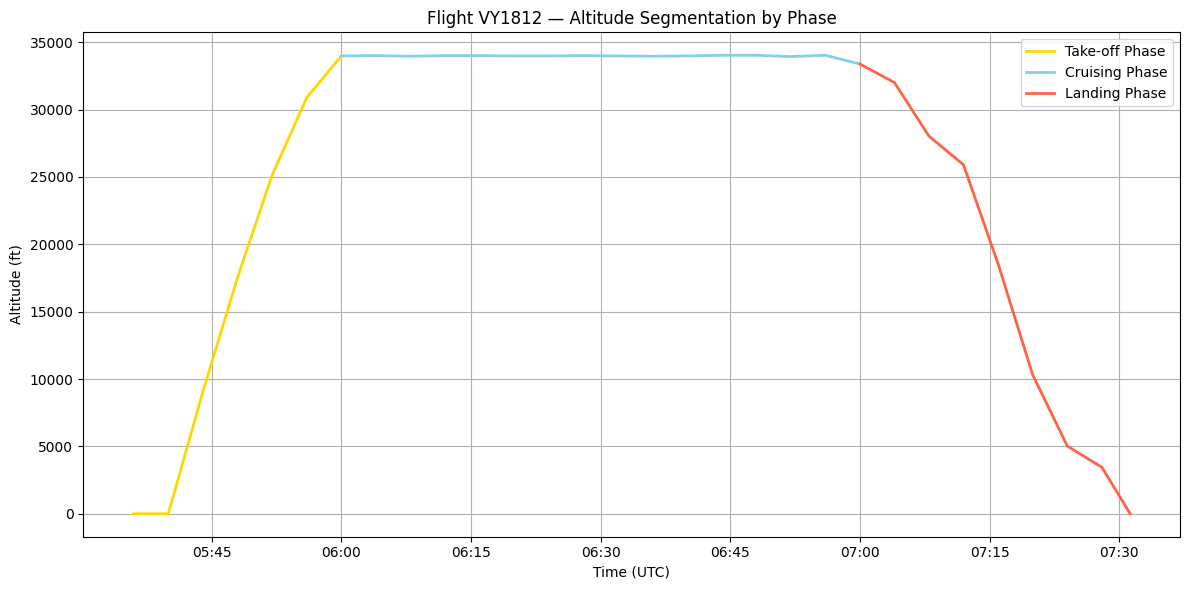

In [2]:
import json
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.dates import DateFormatter, AutoDateLocator

# === Load the phase-separated flight data ===
with open("flight_data_separated_into_phases.json", "r", encoding="utf-8") as f:
    flights = json.load(f)

# === Take the first flight only ===
flight = flights[0]
meta = flight["flight_metadata"]
print(f"Plotting flight: {meta.get('flight')} ({meta.get('fr24_id')})")

# === Convert each phase into a DataFrame ===
def df_from_phase(phase_data):
    if not phase_data:
        return pd.DataFrame(columns=["timestamp", "altitude_ft"])
    df = pd.DataFrame(phase_data)
    if "timestamp" in df.columns:
        df["timestamp"] = pd.to_datetime(df["timestamp"])
    if "altitude_ft" not in df.columns and "alt" in df.columns:
        df.rename(columns={"alt": "altitude_ft"}, inplace=True)
    return df.sort_values("timestamp")

takeoff_df = df_from_phase(flight.get("take_off", []))
cruise_df  = df_from_phase(flight.get("cruising", []))
landing_df = df_from_phase(flight.get("landing", []))

# === Plot altitude vs time with different colors ===
plt.figure(figsize=(12, 6))

if not takeoff_df.empty:
    plt.plot(takeoff_df["timestamp"], takeoff_df["altitude_ft"],
             color="gold", label="Take-off Phase", linewidth=2)
if not cruise_df.empty:
    plt.plot(cruise_df["timestamp"], cruise_df["altitude_ft"],
             color="skyblue", label="Cruising Phase", linewidth=2)
if not landing_df.empty:
    plt.plot(landing_df["timestamp"], landing_df["altitude_ft"],
             color="tomato", label="Landing Phase", linewidth=2)

# === Formatting ===
plt.title(f"Flight {meta.get('flight')} — Altitude Segmentation by Phase")
plt.xlabel("Time (UTC)")
plt.ylabel("Altitude (ft)")
plt.legend()
plt.grid(True)

locator = AutoDateLocator()
formatter = DateFormatter("%H:%M")
plt.gca().xaxis.set_major_locator(locator)
plt.gca().xaxis.set_major_formatter(formatter)

plt.tight_layout()
plt.show()


In [3]:
!pip install openai==0.28

  Using cached openai-0.28.0-py3-none-any.whl (76 kB)
  Attempting uninstall: openai
    Found existing installation: openai 2.16.0
    Uninstalling openai-2.16.0:
      Successfully uninstalled openai-2.16.0


You should consider upgrading via the 'C:\Users\ruben\AppData\Local\Programs\Python\Python310\python.exe -m pip install --upgrade pip' command.


In [4]:
import re

# === JSON cleanup ===
def clean_answer(raw_response: str):
    """
    Cleans and safely parses LLM JSON output (even if wrapped in markdown fences).
    """
    # Remove Markdown code fences (```json ... ```)
    cleaned = re.sub(r"^```(?:json|python)?", "", raw_response.strip(), flags=re.IGNORECASE)
    cleaned = re.sub(r"```$", "", cleaned.strip())

    # Remove common markdown artifacts
    cleaned = cleaned.replace("\n", "\\n").replace("\r", "\\r")

    # Some models may prepend language tag or commentary
    cleaned = re.sub(r"^json", "", cleaned.strip(), flags=re.IGNORECASE)

    # Extra cleanup for accidental trailing commas
    cleaned = re.sub(r",\s*([\]\}])", r"\1", cleaned)

    # Try JSON parsing
    try:
        return json.loads(cleaned)
    except json.JSONDecodeError as e:
        # print(f"⚠️ JSON parsing failed, attempting manual recovery: {e}")
        # # Attempt a secondary cleaning
        cleaned2 = cleaned.replace('\\n', ' ').replace('\\"', '"')
        return json.loads(cleaned2)

In [5]:
import os
import json
from datetime import datetime
from langchain.schema.output_parser import StrOutputParser
from langchain.prompts import ChatPromptTemplate
from langchain.chat_models import ChatOpenAI

# === Model definition ===
# chat_model = ChatOpenAI(model="gpt-4o-2024-11-20", openai_api_key=os.getenv("OPENAI_API_KEY_2"), temperature=0.3)

chat_model = ChatOpenAI(model="gpt-4.1", openai_api_key=os.getenv("OPENAI_API_KEY_2"), temperature=0.3)

# === Prompt (phase-aware, time-referenced, smooth transitions) ===
prompt_phase = """
You are given a segment of flight data corresponding to one phase of a flight 
(either takeoff, cruise, or landing). The data is structured as a list of datapoints, 
each containing the aircraft’s state and environmental conditions at a given time.

Each datapoint is a dictionary with keys such as:
- lat, lon, track, altitude_ft, gspeed (knots), vspeed (ft/min), minutes_since_start (float)
- edr_300hPa, ellrod_300hPa, richardson_number_300hPa, cape,
- wind_speed_10000m, wind_dir_10000m, wind_speed_2m, wind_dir_2m.

Your task is to write a **continuous, expert-level narrative** describing this phase of flight, 
progressing through the datapoints chronologically.

For each datapoint:
1. Use the field `minutes_since_start` to reference time relative to takeoff.
   Example: “5 minutes after departure” (for takeoff) or “5 minutes into the flight” (for cruise/landing).
2. Describe the aircraft's position (lat/lon) and motion (heading, altitude, ground speed, vertical speed).
3. Include meteorological context: turbulence (EDR, Ellrod), stability (Richardson number), CAPE, and wind information.
4. Mention relevant geographic regions based on coordinates (e.g., cities, monuments, regions, landscapes, montains, seas, rivers etc...).
5. Use **smooth transitions** between datapoints:
   - “Then the aircraft turns east by 20° and climbs another 300 ft...”
   - “A few minutes later, it begins a gentle descent...”
   - “As it approaches the Tyrrhenian coast...”
6. Do not forget to include the plane's type at the begining of your description: {type}

Write the result as a natural, continuous, and professional description, not as bullet points. I want to description to be very detailed.

Here is the flight phase's record:
{phase_data}

Return your answer as a JSON list containing the following 3 elements:
["{flight_id}", "{phase_name}", "The flight phase's narrative"]
"""

phase_prompt = ChatPromptTemplate.from_template(prompt_phase)

# === LLM chain definition ===
phase_summary_chain = (
    {
        "type": lambda x: x["type"],
        "phase_data": lambda x: x["data"],
        "flight_id": lambda x: x["fr24_id"],
        "phase_name": lambda x: x["phase"]
    }
    | phase_prompt
    | chat_model
    | StrOutputParser()
)

# === Helper to compute minutes since departure ===
def add_minutes_since_start(phase_data):
    if not phase_data:
        return []
    try:
        timestamps = [datetime.fromisoformat(p["timestamp"].replace("Z", "+00:00")) for p in phase_data]
        t0 = timestamps[0]
        for p, t in zip(phase_data, timestamps):
            delta_min = (t - t0).total_seconds() / 60.0
            p["minutes_since_start"] = round(delta_min, 1)
    except Exception:
        # In case of missing or bad timestamps
        for p in phase_data:
            p["minutes_since_start"] = 0.0
    return phase_data


# === Load dataset ===
with open("flight_data_separated_into_phases.json", "r") as f:
    flights_data = json.load(f)

# === Parameters ===
BATCH_SIZE = 15
total = len(flights_data)
print(f"Processing {total} flights...\n")

all_results = []
failed = []

# === Process flights in batches ===
for batch_start in range(0, total, BATCH_SIZE):
    batch = flights_data[batch_start:batch_start + BATCH_SIZE]
    print(f"🧩 Batch {(batch_start // BATCH_SIZE) + 1}: flights {batch_start + 1}–{batch_start + len(batch)}")

    # Step 1. Build the list of phase requests
    phase_requests = []
    flight_index = {}  # To map (flight_id, phase) back to all_results

    for flight in batch:
        fr24_id = flight["flight_metadata"]["fr24_id"]
        type = flight["flight_metadata"]["type"]
        for phase_name in ["take_off", "cruising", "landing"]:
            phase_data = add_minutes_since_start(flight.get(phase_name, []))
            if not phase_data:
                continue
            req = {"type": type, "phase": phase_name, "data": phase_data, "fr24_id": fr24_id}
            phase_requests.append(req)
            flight_index[(fr24_id, phase_name)] = None  # placeholder

    print(f"  🚀 Sending {len(phase_requests)} phase requests to GPT...")

    # Step 2. Send all at once
    try:
        responses = phase_summary_chain.batch(phase_requests, {"max_concurrency": BATCH_SIZE*3})
    except Exception as e:
        print(f"  ❌ Batch request failed: {e}")
        failed.extend([(r['fr24_id'], r['phase']) for r in phase_requests])
        continue

    # Step 3. Parse each response and assign to the correct (flight, phase)
    for raw_response, req in zip(responses, phase_requests):
        fr24_id, phase_name = req["fr24_id"], req["phase"]
        try:
            parsed = clean_answer(raw_response)
            # expected [flight_id, phase_name, narrative]
            narrative = parsed[2]
            flight_index[(fr24_id, phase_name)] = narrative
            print(f"  ✅ Parsed {fr24_id} ({phase_name})")
        except Exception as e:
            print(f"  ⚠️ Parsing failed for {fr24_id} ({phase_name}): {e}")
            failed.append((fr24_id, phase_name))

    # Step 4. Assemble results for flights in this batch
    for flight in batch:
        fr24_id = flight["flight_metadata"]["fr24_id"]
        result_entry = {
            "fr24_id": fr24_id,
            "take_off": flight_index.get((fr24_id, "take_off"), "No data or failed."),
            "cruising": flight_index.get((fr24_id, "cruising"), "No data or failed."),
            "landing": flight_index.get((fr24_id, "landing"), "No data or failed.")
        }
        all_results.append(result_entry)

    print(f"✅ Completed batch {(batch_start // BATCH_SIZE) + 1}\n")

# === Save output ===
output_path = "flight_summary_separated_into_phases.json"
with open(output_path, "w", encoding="utf-8") as f:
    json.dump(all_results, f, indent=2, ensure_ascii=False)

print(f"\n✅ All flights processed. Results saved to {output_path}")
if failed:
    print(f"⚠️ {len(failed)} failed phases: {failed}")


Processing 628 flights...

🧩 Batch 1: flights 1–15
  🚀 Sending 45 phase requests to GPT...
  ✅ Parsed 39b3674c (take_off)
  ✅ Parsed 39b3674c (cruising)
  ✅ Parsed 39b3674c (landing)
  ✅ Parsed 39b6dc82 (take_off)
  ✅ Parsed 39b6dc82 (cruising)
  ✅ Parsed 39b6dc82 (landing)
  ✅ Parsed 39ba46eb (take_off)
  ✅ Parsed 39ba46eb (cruising)
  ✅ Parsed 39ba46eb (landing)
  ✅ Parsed 39bde314 (take_off)
  ✅ Parsed 39bde314 (cruising)
  ✅ Parsed 39bde314 (landing)
  ✅ Parsed 39c197d1 (take_off)
  ✅ Parsed 39c197d1 (cruising)
  ✅ Parsed 39c197d1 (landing)
  ✅ Parsed 39c4e039 (take_off)
  ✅ Parsed 39c4e039 (cruising)
  ✅ Parsed 39c4e039 (landing)
  ✅ Parsed 39c83e78 (take_off)
  ✅ Parsed 39c83e78 (cruising)
  ✅ Parsed 39c83e78 (landing)
  ✅ Parsed 39cbe7f7 (take_off)
  ✅ Parsed 39cbe7f7 (cruising)
  ✅ Parsed 39cbe7f7 (landing)
  ✅ Parsed 39cfcbde (take_off)
  ✅ Parsed 39cfcbde (cruising)
  ✅ Parsed 39cfcbde (landing)
  ✅ Parsed 39d3e6f3 (take_off)
  ✅ Parsed 39d3e6f3 (cruising)
  ✅ Parsed 39d3e6f3

In [6]:
!pip install --upgrade openai

  Attempting uninstall: openai
    Found existing installation: openai 0.28.0
    Uninstalling openai-0.28.0:
      Successfully uninstalled openai-0.28.0


You should consider upgrading via the 'C:\Users\ruben\AppData\Local\Programs\Python\Python310\python.exe -m pip install --upgrade pip' command.


✅ Common flights: 628

🧠 Building FAISS index for phase: take_off
✅ Phase 'take_off': added 628 valid flights.

🧠 Building FAISS index for phase: cruising
✅ Phase 'cruising': added 628 valid flights.

🧠 Building FAISS index for phase: landing
✅ Phase 'landing': added 628 valid flights.

✅ All FAISS indices built successfully.


✅ Valid target flights (with all 3 phases): 628
🎯 Target flight: 39b3674c

🔹 Analyzing phase: take_off
Top-5 similar flights (take_off): ('3a2fc430', '3a5fec01', '3a951cfa', '39c1c8fc', '39d9f583')
Bottom-5 dissimilar flights (take_off): ('3aac6bd6', '3a89221d', '3a1d1d29', '3a058cb9', '3a2ac8c5')


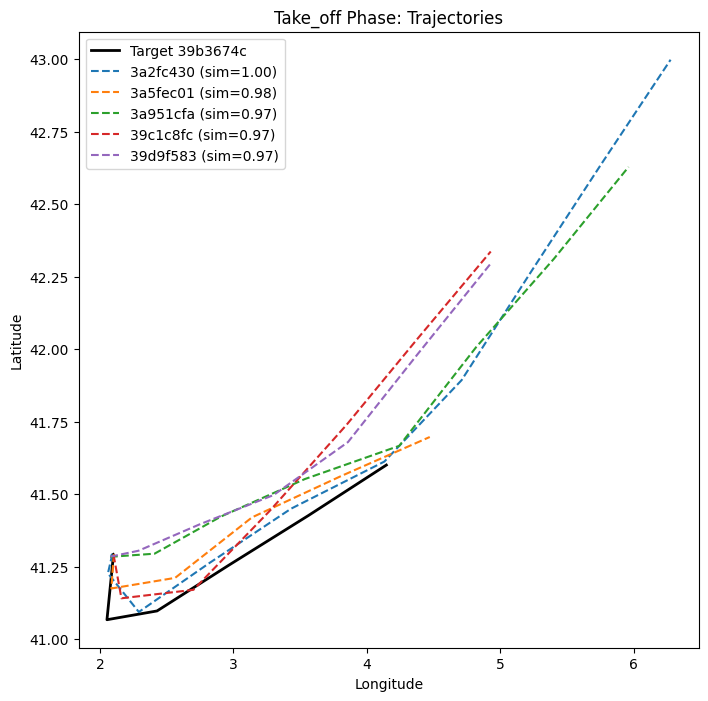

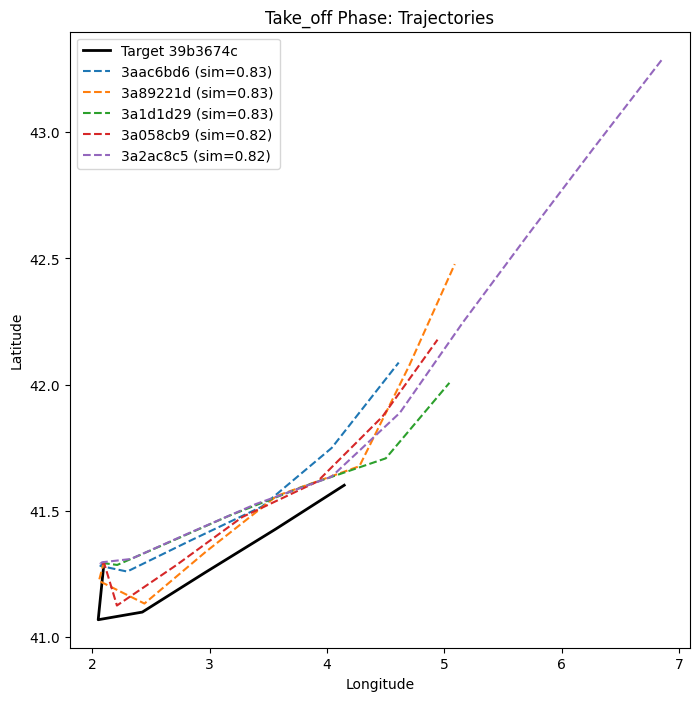

🔹 Analyzing phase: cruising
Top-5 similar flights (cruising): ('3a2fc430', '3a5fec01', '3a951cfa', '39c1c8fc', '39d9f583')
Bottom-5 dissimilar flights (cruising): ('3aac6bd6', '3a89221d', '3a1d1d29', '3a058cb9', '3a2ac8c5')


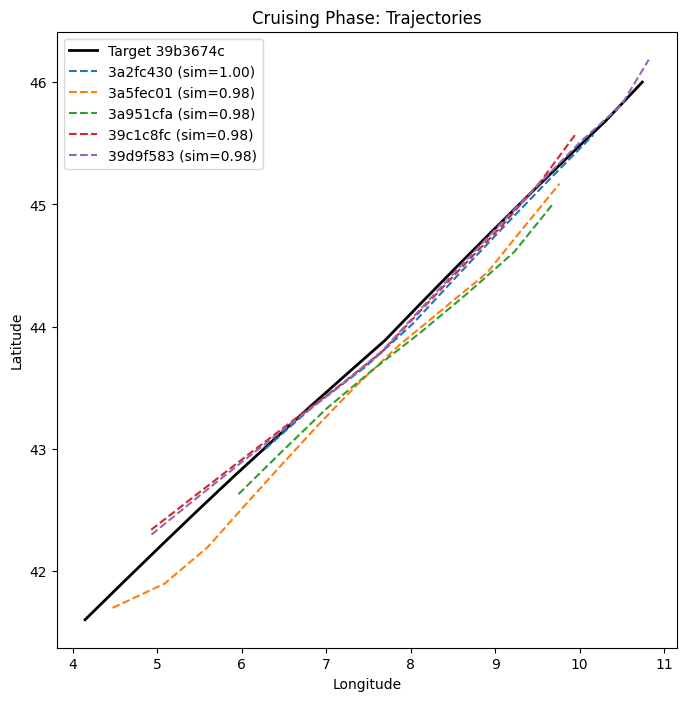

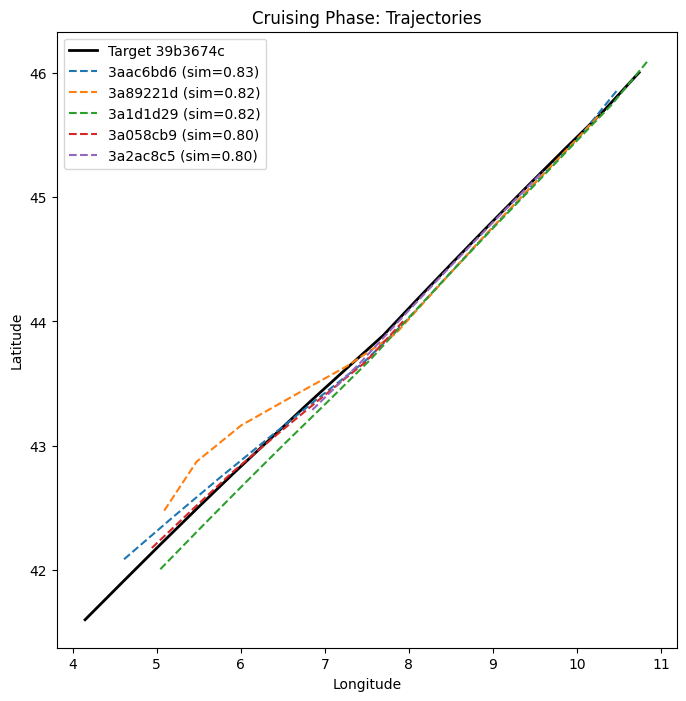

🔹 Analyzing phase: landing
Top-5 similar flights (landing): ('3a2fc430', '3a5fec01', '3a951cfa', '39c1c8fc', '39d9f583')
Bottom-5 dissimilar flights (landing): ('3aac6bd6', '3a89221d', '3a1d1d29', '3a058cb9', '3a2ac8c5')


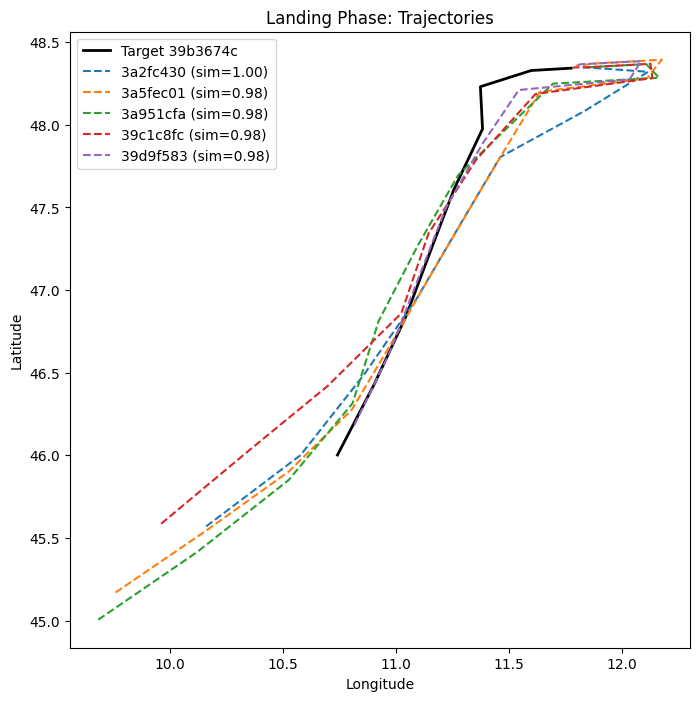

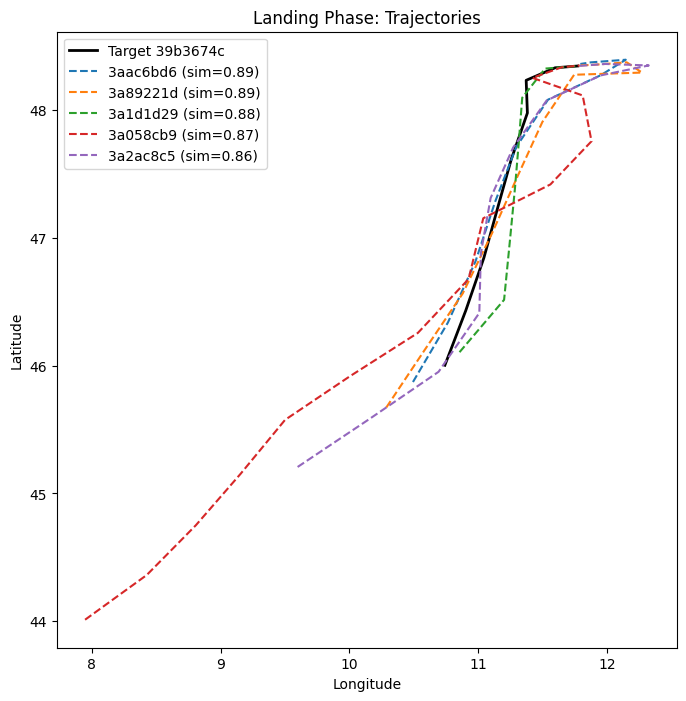

In [7]:
# !pip install openai faiss-cpu matplotlib

import os
import json
import faiss
import numpy as np
import matplotlib.pyplot as plt
from datetime import datetime
from openai import OpenAI

# --------------------------
# Config
# --------------------------
MODEL = "text-embedding-3-large"
client = OpenAI(api_key=os.getenv("OPENAI_API_KEY_2"))
K = 5  # number of most similar/dissimilar flights
PHASES = ["take_off", "cruising", "landing"]

# --------------------------
# Load summaries and data
# --------------------------
with open("flight_summary_separated_into_phases.json", "r", encoding="utf-8") as f:
    summaries = json.load(f)

with open("flight_data_separated_into_phases.json", "r", encoding="utf-8") as f:
    flights_data = json.load(f)

# Map fr24_id -> raw data per phase
data_by_id = {f["flight_metadata"]["fr24_id"]: f for f in flights_data}

# Map fr24_id -> summaries per phase, safely handling nulls
summary_by_phase = {}
for s in summaries:
    fid = s["fr24_id"]
    summary_by_phase[fid] = {}
    for phase in PHASES:
        text = s.get(phase)
        summary_by_phase[fid][phase] = text if isinstance(text, str) and text.strip() else None

common_ids = list(set(summary_by_phase.keys()) & set(data_by_id.keys()))
print(f"✅ Common flights: {len(common_ids)}")

# --------------------------
# Embeddings helper
# --------------------------
def get_embeddings(texts, model=MODEL, batch_size=64):
    vectors = []
    total = len(texts)
    for i in range(0, total, batch_size):
        batch = texts[i:i + batch_size]
        resp = client.embeddings.create(model=model, input=batch)
        batch_vecs = [np.array(e.embedding, dtype="float32") for e in resp.data]
        vectors.extend(batch_vecs)
    X = np.vstack(vectors)
    X = X / np.linalg.norm(X, axis=1, keepdims=True)  # L2 normalization
    return X

# --------------------------
# Build FAISS index per phase (robust to missing summaries)
# --------------------------
phase_indices = {}
phase_metas = {}

for phase in PHASES:
    print(f"\n🧠 Building FAISS index for phase: {phase}")
    valid_flights = [fid for fid in common_ids if summary_by_phase[fid].get(phase)]
    texts = [summary_by_phase[fid][phase] for fid in valid_flights]
    if not texts:
        print(f"⚠️ No valid flights for phase {phase}, skipping index.")
        continue

    E = get_embeddings(texts)
    d = E.shape[1]
    index = faiss.IndexFlatIP(d)
    index.add(E)
    phase_indices[phase] = index
    phase_metas[phase] = valid_flights
    print(f"✅ Phase '{phase}': added {len(valid_flights)} valid flights.")

print("\n✅ All FAISS indices built successfully.\n")

# --------------------------
# Compute similarities per phase
# --------------------------
def find_similar_and_dissimilar(target_id, phase, k=K):
    """Find top-k and bottom-k flights for a given phase."""
    if phase not in phase_indices:
        raise ValueError(f"No index built for phase '{phase}'.")
    if not summary_by_phase[target_id].get(phase):
        raise ValueError(f"Target flight {target_id} has no data for phase '{phase}'.")

    q_vec = get_embeddings([summary_by_phase[target_id][phase]])
    index = phase_indices[phase]
    sims, idxs = index.search(q_vec, len(phase_metas[phase]))
    sims, idxs = sims[0], idxs[0]

    pairs = [
        (phase_metas[phase][i], float(sims[i]))
        for i in range(len(sims))
        if phase_metas[phase][i] != target_id
    ]
    pairs.sort(key=lambda x: x[1], reverse=True)
    return pairs[:k], pairs[-k:], pairs

# --------------------------
# Helpers for plotting
# --------------------------
def parse_time(ts):
    return datetime.fromisoformat(ts.replace("Z", "+00:00"))

def extract_phase_data(fid, phase):
    phase_data = data_by_id[fid].get(phase, [])
    if not phase_data:
        return [], [], [], []
    times = [parse_time(d["timestamp"]) for d in phase_data]
    alts = [d.get("altitude_ft", 0) for d in phase_data]
    lats = [d.get("lat", 0) for d in phase_data]
    lons = [d.get("lon", 0) for d in phase_data]
    return times, alts, lats, lons

def plot_altitude_phase(target_id, compare_ids, compare_sims, phase):
    plt.figure(figsize=(10,6))
    t, v, *_ = extract_phase_data(target_id, phase)
    if not t:
        print(f"⚠️ No altitude data for target {target_id} phase {phase}")
        return
    plt.plot(t, v, label=f"Target {target_id}", linewidth=2, color="black")
    for cid, sim in zip(compare_ids, compare_sims):
        t, v, *_ = extract_phase_data(cid, phase)
        if not t: 
            continue
        plt.plot(t, v, linestyle="--", label=f"{cid} (sim={sim:.2f})")
    plt.title(f"{phase.capitalize()} Phase: Altitude Comparison")
    plt.ylabel("Altitude (ft)")
    plt.xlabel("Time (UTC)")
    plt.legend()
    plt.show()

def plot_trajectory_phase(target_id, compare_ids, compare_sims, phase):
    plt.figure(figsize=(8,8))
    *_, lat, lon = extract_phase_data(target_id, phase)
    if not lat:
        print(f"⚠️ No trajectory data for target {target_id} phase {phase}")
        return
    plt.plot(lon, lat, label=f"Target {target_id}", linewidth=2, color="black")
    for cid, sim in zip(compare_ids, compare_sims):
        *_, lat, lon = extract_phase_data(cid, phase)
        if not lat:
            continue
        plt.plot(lon, lat, linestyle="--", label=f"{cid} (sim={sim:.2f})")
    plt.title(f"{phase.capitalize()} Phase: Trajectories")
    plt.xlabel("Longitude")
    plt.ylabel("Latitude")
    plt.legend()
    plt.show()

# --------------------------
# Identify valid target flights
# --------------------------
valid_targets = [
    fid for fid, phases in summary_by_phase.items()
    if all(phases.get(p) for p in PHASES)
]
print(f"\n✅ Valid target flights (with all 3 phases): {len(valid_targets)}")

if not valid_targets:
    raise ValueError("No complete flights found with all phases!")

target_id = valid_targets[0]
print(f"🎯 Target flight: {target_id}\n")

# --------------------------
# Similarity + Visualization per phase
# --------------------------
for phase in PHASES:
    if phase not in phase_indices:
        print(f"⚠️ Skipping {phase}: no index built.")
        continue
    print(f"🔹 Analyzing phase: {phase}")
    try:
        top, bottom, ranking = find_similar_and_dissimilar(target_id, phase, k=K)
    except ValueError as e:
        print(f"⚠️ {e}")
        continue

    if not top or not bottom:
        print(f"⚠️ Not enough data for phase {phase}.")
        continue

    top_ids, top_sims = zip(*top)
    bottom_ids, bottom_sims = zip(*bottom)

    print(f"Top-{K} similar flights ({phase}): {top_ids}")
    print(f"Bottom-{K} dissimilar flights ({phase}): {bottom_ids}")

    plot_trajectory_phase(target_id, top_ids, top_sims, phase)
    plot_trajectory_phase(target_id, bottom_ids, bottom_sims, phase)


In [8]:
import json
from datetime import datetime
import copy

def enrich_with_minutes_since_start(phase_data):
    """Ajoute le champ minutes_since_start basé sur le premier timestamp de la phase."""
    if not phase_data or len(phase_data) < 1:
        return []

    enriched = copy.deepcopy(phase_data)
    t0 = datetime.fromisoformat(enriched[0]["timestamp"].replace("Z", "+00:00"))

    for dp in enriched:
        t = datetime.fromisoformat(dp["timestamp"].replace("Z", "+00:00"))
        dp["minutes_since_start"] = round((t - t0).total_seconds() / 60, 2)

    return enriched

# === Charger les données brutes ===
with open("flight_data_separated_into_phases.json", "r", encoding="utf-8") as f:
    flights = json.load(f)

# === Enrichir toutes les phases de tous les vols ===
for flight in flights:
    for phase in ["take_off", "cruising", "landing"]:
        if phase in flight and isinstance(flight[phase], list):
            flight[phase] = enrich_with_minutes_since_start(flight[phase])


In [9]:
flights[0]

{'flight_metadata': {'flight': 'VY1812',
  'callsign': 'VLG9VG',
  'source': 'ADSB',
  'hex': '345314',
  'type': 'A321',
  'reg': 'EC-MOO',
  'painted_as': 'VLG',
  'operating_as': 'VLG',
  'orig_iata': 'BCN',
  'orig_icao': 'LEBL',
  'dest_iata': 'MUC',
  'dest_icao': 'EDDM',
  'eta': None,
  'fr24_id': '39b3674c'},
 'take_off': [{'lat': 41.29257,
   'lon': 2.09878,
   'track': 64,
   'altitude_ft': 0,
   'gspeed': 13,
   'vspeed': 0,
   'squawk': '5332',
   'timestamp': '2025-04-01 05:35:54+00:00',
   'edr_300hPa_m23s1': 0.027,
   'turbulence_ellrod_300hPa_s2': 1.9,
   'richardson_number_300hPa_idx': 10.0,
   'turbulence_cape_m23s': 0.0,
   'wind_speed_10000m_ms': 25.9,
   'wind_dir_10000m_d': 352.4,
   'wind_speed_2m_ms': 0.1,
   'wind_dir_2m_d': 283.4,
   'minutes_since_start': 0.0},
  {'lat': 41.29124,
   'lon': 2.10042,
   'track': 247,
   'altitude_ft': 0,
   'gspeed': 51,
   'vspeed': 0,
   'squawk': '5332',
   'timestamp': '2025-04-01 05:39:59+00:00',
   'edr_300hPa_m23s1': 0

In [10]:
# === Sauvegarder dans un nouveau fichier ===
output_path = "flight_data_with_minutes_since_start.json"
with open(output_path, "w", encoding="utf-8") as f:
    json.dump(flights, f, indent=2, ensure_ascii=False)

print(f"✅ Données enrichies enregistrées dans {output_path}")

✅ Données enrichies enregistrées dans flight_data_with_minutes_since_start.json


In [11]:
import json
from openai import OpenAI
import os
import faiss
import numpy as np
import matplotlib.pyplot as plt
from datetime import datetime
from pathlib import Path

# === Configuration ===
MODEL = "gpt-4.1"
client = OpenAI(api_key=os.getenv("OPENAI_API_KEY_2"))
PHASES = ["take_off", "cruising", "landing"]

# === Prompt de résumé phase (tu l’utilises déjà) ===
PROMPT_PHASE_TEMPLATE = """
You are given a segment of flight data corresponding to the {phase_name} phase of a flight. The data is structured as a list of datapoints, 
each containing the aircraft’s state and environmental conditions at a given time.

Each datapoint is a dictionary with keys such as:
- lat, lon, track, altitude_ft, gspeed (knots), vspeed (ft/min), minutes_since_start (float)
- edr_300hPa, ellrod_300hPa, richardson_number_300hPa, cape,
- wind_speed_10000m, wind_dir_10000m, wind_speed_2m, wind_dir_2m.

Your task is to write a **continuous, expert-level narrative** describing this phase of flight, 
progressing through the datapoints chronologically.

For each datapoint:
1. Use the field `minutes_since_start` to reference time relative to takeoff.
   Example: “5 minutes after departure” (for takeoff) or “5 minutes into the flight” (for cruise/landing).
2. Describe the aircraft's position (lat/lon) and motion (heading, altitude, ground speed, vertical speed).
3. Include meteorological context: turbulence (EDR, Ellrod), stability (Richardson number), CAPE, and wind information.
4. Mention relevant geographic regions based on coordinates (e.g., cities, monuments, regions, landscapes, montains, seas, rivers etc...).
5. Use **smooth transitions** between datapoints:
   - “Then the aircraft turns east by 20° and climbs another 300 ft...”
   - “A few minutes later, it begins a gentle descent...”
   - “As it approaches the Tyrrhenian coast...”
6. Do not forget to include the plane's type at the begining of your description: {type}

Write the result as a natural, continuous, and professional description, not as bullet points. I want to description to be very detailed.

Here is the flight phase's record:
{phase_data}

Return the flights summary without any metatext"""

# === Génère le résumé via OpenAI pour n points de données ===
def generate_summary(phase_name, phase_data, aircraft_type, target_flight_id):

    prompt = PROMPT_PHASE_TEMPLATE.format(
        phase_name=phase_name,
        phase_data=json.dumps(phase_data),
        type=aircraft_type
    )
    response = client.chat.completions.create(
        model=MODEL,
        messages=[{"role": "user", "content": prompt}],
        temperature=0.3
    )
    parsed = response.choices[0].message.content.strip()
    return parsed # narrative only



# === Construit le prompt final de prédiction ===
def build_prediction_prompt(target_summary, similar_summaries, N):
    prompt = f"""The target flight entered a GPS spoofed zone. Here is its trajectory summary before spoofing:
{target_summary}

Here are the summaries of the 5 most similar flights:"""
    for i, summ in enumerate(similar_summaries):
        prompt += f"\n\nSimilar flight {i+1}:\n{summ}"

    prompt += f"""

Based on these flights, where will the target flight be {N} minutes after the start of the phase?

⚠️ Return only the predicted position in this exact format:
LATITUDE, LONGITUDE
"""
    return prompt

# === Appel LLM pour la prédiction ===
def predict_position(prompt):
    response = client.chat.completions.create(
        model=MODEL,
        messages=[{"role": "user", "content": prompt}],
        temperature=0
    )
    return response.choices[0].message.content.strip()

In [12]:
import os
import json
import faiss
from openai import OpenAI
from dotenv import load_dotenv
load_dotenv()

client = OpenAI(api_key=os.getenv("OPENAI_API_KEY_2"))

# --------------------------
# CONFIGURATION
# --------------------------
EMBED_MODEL = "text-embedding-3-large"
LLM_MODEL = "gpt-4.1"
K = 6  # number of similar flights retrieved
PHASE = "take_off"  # phase we test
EMBEDDINGS_PATH = "EMBEDDINGS"

# --------------------------
# LOAD DATA
# --------------------------
with open("flight_data_with_minutes_since_start.json", "r", encoding="utf-8") as f:
    flights_data = json.load(f)

with open("flight_summary_separated_into_phases.json", "r", encoding="utf-8") as f:
    summaries = json.load(f)

data_by_id = {f["flight_metadata"]["fr24_id"]: f for f in flights_data}
summary_by_phase = {
    s["fr24_id"]: {p: s.get(p, None) for p in ["take_off", "cruising", "landing"]}
    for s in summaries
}

print(f"✅ Loaded {len(flights_data)} flights with data and summaries.\n")


def save_phase_index(phase, index, ids, embeddings):
    faiss.write_index(index, f"{EMBEDDINGS_PATH}/faiss_index_{phase}.index")
    np.save(f"{EMBEDDINGS_PATH}/embeddings_{phase}.npy", embeddings)
    with open(f"{EMBEDDINGS_PATH}/ids_{phase}.json", "w") as f:
        json.dump(ids, f)
    print(f"💾 Saved FAISS index, embeddings and IDs for phase '{phase}'")


def load_phase_index(phase):
    index = faiss.read_index(f"{EMBEDDINGS_PATH}/faiss_index_{phase}.index")
    embeddings = np.load(f"{EMBEDDINGS_PATH}/embeddings_{phase}.npy")
    with open(f"{EMBEDDINGS_PATH}/ids_{phase}.json", "r") as f:
        ids = json.load(f)
    print(f"📂 Loaded FAISS index, embeddings and IDs for phase '{phase}'")
    return index, ids, embeddings

# --------------------------
# EMBEDDING HELPER
# --------------------------
def get_embeddings(texts, model=EMBED_MODEL, batch_size=32):
    """Embed multiple texts with normalization."""
    vecs = []
    for i in range(0, len(texts), batch_size):
        batch = texts[i:i+batch_size]
        resp = client.embeddings.create(model=model, input=batch)
        embs = [np.array(e.embedding, dtype="float32") for e in resp.data]
        vecs.extend(embs)
    X = np.vstack(vecs)
    X /= np.linalg.norm(X, axis=1, keepdims=True)
    return X

# --------------------------
# BUILD RAG INDEX FOR EACH PHASE
# --------------------------

def build_phase_index(phase, force_rebuild=False):
    # 1) If files exist → load them
    if (not force_rebuild and 
        os.path.exists(f"{EMBEDDINGS_PATH}/faiss_index_{phase}.index") and
        os.path.exists(f"{EMBEDDINGS_PATH}/embeddings_{phase}.npy") and
        os.path.exists(f"{EMBEDDINGS_PATH}/ids_{phase}.json")):

        return load_phase_index(phase)

    # 2) Else → rebuild the index
    valid = [fid for fid, s in summary_by_phase.items() if s.get(phase)]
    texts = [summary_by_phase[fid][phase] for fid in valid]

    if not texts:
        raise ValueError(f"No valid summaries for phase '{phase}'")

    E = get_embeddings(texts)
    d = E.shape[1]

    index = faiss.IndexFlatIP(d)
    index.add(E)

    print(f"🔧 Index built for phase '{phase}' with {len(valid)} flights")

    # 3) Save everything for next time
    save_phase_index(phase, index, valid, E)

    return index, valid, E

✅ Loaded 628 flights with data and summaries.



In [13]:
phase_index_take_off, phase_ids_take_off, _ = build_phase_index("take_off")
phase_index_cruising, phase_ids_cruising, _ = build_phase_index("cruising")
phase_index_landing, phase_ids_landing, _ = build_phase_index("landing")

🔧 Index built for phase 'take_off' with 628 flights
💾 Saved FAISS index, embeddings and IDs for phase 'take_off'
🔧 Index built for phase 'cruising' with 628 flights
💾 Saved FAISS index, embeddings and IDs for phase 'cruising'
🔧 Index built for phase 'landing' with 628 flights
💾 Saved FAISS index, embeddings and IDs for phase 'landing'


In [14]:
index_dictionary = {"take_off": phase_index_take_off, "cruising": phase_index_cruising, "landing": phase_index_landing}
ids_dictionary = {"take_off": phase_ids_take_off, "cruising": phase_ids_cruising, "landing": phase_ids_landing}

In [15]:
import re

# === JSON cleanup ===
def clean_answer(raw_response: str):
    """
    Cleans and safely parses LLM JSON output (even if wrapped in markdown fences).
    """
    # Remove Markdown code fences (```json ... ```)
    cleaned = re.sub(r"^```(?:json|python)?", "", raw_response.strip(), flags=re.IGNORECASE)
    cleaned = re.sub(r"```$", "", cleaned.strip())

    # Remove common markdown artifacts
    cleaned = cleaned.replace("\n", "\\n").replace("\r", "\\r")

    # Some models may prepend language tag or commentary
    cleaned = re.sub(r"^json", "", cleaned.strip(), flags=re.IGNORECASE)

    # Extra cleanup for accidental trailing commas
    cleaned = re.sub(r",\s*([\]\}])", r"\1", cleaned)

    # Try JSON parsing
    try:
        return json.loads(cleaned)
    except json.JSONDecodeError as e:
        # print(f"⚠️ JSON parsing failed, attempting manual recovery: {e}")
        # # Attempt a secondary cleaning
        cleaned2 = cleaned.replace('\\n', ' ').replace('\\"', '"')
        return json.loads(cleaned2)

In [16]:
PREDICT_POSITION_PROMPT = f"""
A flight entered a GPS spoofing zone. Therefore his position is now unknown and your task is to help the pilot 
by predicting the flight's latitude and longitude.
Here is its known trajectory (before spoofing):

{{partial_summary}}

The following are summaries of {{number_similar_flight}} similar flights for the same phase:

{{sim_text}}

{{predictions_history}}

Based on these, predict the geographic position of the target flight {{predict_minutes}} minutes after the beginning of the phase.
Return your answer as JSON: {{{{"lat": "the predicted latitude", "lon": "the predicted longitude"}}}} only.
"""

# --------------------------
# PREDICT POSITION VIA LLM
# --------------------------
def predict_position_from_prompt(partial_summary, similar_summaries, predict_minutes, prediction_history: list=[]):
    """Ask GPT to predict target position after N minutes using similar flights."""
    sim_text = "\n\n".join([f"Similar flight {i+1}:\n{txt}" for i, txt in enumerate(similar_summaries)])
    if not prediction_history:
        predictions_history = ""
    else:
        predictions_history = f"""Here are the predictions you already made. They are given as a list of triplet [latitude, longitude, number of minutes into the phase]. Use these past predictions to ensure that your next prediction is consistent.
Make sure the plane continues moving forward along its trajectory, does not remain at the same coordinates repeatedly, and does not move backward in a way that violates realistic flight dynamics.

PREDICTION HISTORY: {{prediction_history}}"""
        predictions_history = predictions_history.format(prediction_history=prediction_history)

    prompt = PREDICT_POSITION_PROMPT.format(
        partial_summary=partial_summary, 
        number_similar_flight=len(similar_summaries),
        sim_text=sim_text,
        predict_minutes=predict_minutes,
        predictions_history=predictions_history,
    )

    response = client.chat.completions.create(
        model="gpt-4.1",
        messages=[{"role": "user", "content": prompt}],
        temperature=0
    )
        
    return clean_answer(response.choices[0].message.content), response.usage.total_tokens


In [17]:
# --------------------------
# FIND SIMILAR FLIGHTS
# --------------------------
def find_similar_flights(partial_summary, target_id, phase, k=K, batch_size=None):
    """Embed the target partial summary and find K most similar full summaries."""
    q_vec = get_embeddings([partial_summary])
    sims, idxs = index_dictionary[phase].search(q_vec, k)
    ids_for_phase = ids_dictionary[phase]
    sims, idxs = sims[0], idxs[0]
    neighbors = [(ids_for_phase[i], float(sims[i])) for i in range(len(idxs)) if ids_for_phase[i] != target_id]
    return neighbors


In [20]:
import matplotlib.pyplot as plt
import math

# ================================================
# CONFIGURATION EXPERIMENTALE
# ================================================

K = 5        # number of similar flights to retrieve

def get_mean_similar_flights_position(similar_ids, data_by_id, phase, t_min):
    """
    Computes the mean latitude and longitude of the similar flights at the point
    closest to t_min in terms of minutes_since_start.
    """

    latitudes = []
    longitudes = []

    for fid in similar_ids:
        flight = data_by_id.get(fid)
        if not flight:
            continue

        phase_data = flight.get(phase)
        if not phase_data or len(phase_data) == 0:
            continue

        # Find the point in the similar flight closest to t_min
        closest_point = min(
            phase_data,
            key=lambda p: abs(p["minutes_since_start"] - t_min)
        )

        lat = closest_point.get("lat", None)
        lon = closest_point.get("lon", None)

        if lat is not None and lon is not None:
            latitudes.append(lat)
            longitudes.append(lon)

    # If no valid positions were found
    if len(latitudes) == 0:
        return (None, None)

    # Compute mean
    mean_lat = sum(latitudes) / len(latitudes)
    mean_lon = sum(longitudes) / len(longitudes)

    return [mean_lat, mean_lon, t_min]

def haversine(lat1, lon1, lat2, lon2):
    R = 6371e3
    phi1, phi2 = math.radians(lat1), math.radians(lat2)
    dphi = math.radians(lat2 - lat1)
    dlambda = math.radians(lon2 - lon1)
    a = math.sin(dphi/2)**2 + math.cos(phi1)*math.cos(phi2)*math.sin(dlambda/2)**2
    return R * 2 * math.atan2(math.sqrt(a), math.sqrt(1-a))

def predict_flight(flight_id, phase, with_feedback_loop=True, k=K, batch_size=None):
    # --------------------------
    # 1️⃣ Extraire les données du vol cible
    # --------------------------
    target_flight = data_by_id[flight_id]
    phase_data = target_flight[phase]
    aircraft_type = target_flight["flight_metadata"]["type"]

    # --------------------------
    # 2️⃣ Définir la zone de spoofing
    # --------------------------
    N = len(phase_data)
    SPOOF_INDEX = N // 2   # floor division → produit exactement la séparation souhaitée

    # print(f"📏 Phase length = {N} points — Observed = 0:{SPOOF_INDEX-1}, Predicted = {SPOOF_INDEX}:{N-1}")

    observed_data = phase_data[:SPOOF_INDEX]
    spoofed_data  = phase_data[SPOOF_INDEX:]

    # --------------------------
    # 3️⃣ Générer le résumé partiel (RAG query)
    # --------------------------
    partial_summary = generate_summary(phase, observed_data, aircraft_type, flight_id)
    # print("🧩 Résumé partiel généré.\n")

    # --------------------------
    # 5️⃣ Prédire tous les points de la zone spoofée
    # --------------------------
    predicted_positions = []
    ground_truth_positions = []
    mean_similar_flights_position = []

    for i, point in enumerate(spoofed_data):
        t_min = point["minutes_since_start"]
        barometric_altitude = point["altitude_ft"]

        # --------------------------
        # 4️⃣ Trouver les vols similaires en prenant en compte l'altitude connu
        # --------------------------
        altitude_prompt = f"""{t_min} minutes into the {phase} phase, the aircraft reached an altitude of {barometric_altitude} feet."""
        partial_summary = f"""{partial_summary} {altitude_prompt}"""
        neighbors = find_similar_flights(partial_summary, target_id=flight_id, phase=phase, k=k, batch_size=batch_size)
        similar_ids = [fid for fid, sim in neighbors]
        similar_summaries = [summary_by_phase[fid][phase] for fid in similar_ids]

        # print(f"🔍 {len(similar_ids)} vols similaires trouvés :", similar_ids, "\n")

        # print(f"⏳ Prédiction point {SPOOF_INDEX+i} (t = {t_min} min)")

        if with_feedback_loop:
            prediction, num_token = predict_position_from_prompt(
                partial_summary,
                similar_summaries,
                predict_minutes=t_min,
                prediction_history=predicted_positions
            )
        else:
            prediction, num_token = predict_position_from_prompt(
                partial_summary,
                similar_summaries,
                predict_minutes=t_min
            )

        if prediction:
            predicted_positions.append([float(prediction["lat"]), float(prediction["lon"]), t_min]) # 

        ground_truth_positions.append([point["lat"], point["lon"], t_min])
        mean_similar_flights_position.append(get_mean_similar_flights_position(similar_ids, data_by_id, phase, t_min))

    mean_error = 0
    mean_similar_flight_error = 0

    for i in range(len(predicted_positions)):
        predicted_point = predicted_positions[i]
        lat1 = predicted_point[0]
        lon1 = predicted_point[1]
        ground_truth_point = ground_truth_positions[i]
        lat2 = ground_truth_point[0]
        lon2 = ground_truth_point[1]
        error = haversine(lat1, lon1, lat2, lon2)
        mean_error += error

        lat1 = mean_similar_flights_position[i][0]
        lon1 = mean_similar_flights_position[i][1]
        error = haversine(lat1, lon1, lat2, lon2)
        mean_similar_flight_error += error

    mean_error = mean_error / len(predicted_positions)
    mean_similar_flight_error = mean_similar_flight_error / len(mean_similar_flights_position)
    # print(f"📌 Avg Error = {mean_error:.2f} meters")

    return observed_data, ground_truth_positions, predicted_positions, round(mean_error/1000, 1), mean_similar_flights_position, round(mean_similar_flight_error/1000, 1), num_token

# ================================================
# FONCTION PRINCIPALE DE L'EXPÉRIENCE
# ================================================
def run_experiment_for_flight(flight_id, phase, with_feedback_loop: bool = False, json_path="results_RAG.json"):
    print("\n=================================================")
    print(f"🚀 EXPÉRIMENTATION SUR VOL {flight_id} | PHASE = {phase}")
    print("=================================================\n")

    observed_data, ground_truth_positions, predicted_positions, mean_error, mean_similar_flights_position, _, _ = predict_flight(flight_id, phase, with_feedback_loop=True)

    # save_RAG_results(
    #     json_path=json_path,
    #     phase_name=phase,
    #     observed=observed_data,
    #     ground_truth=ground_truth_positions,
    #     predicted=predicted_positions,
    #     mean_error=mean_error,
    #     mean_similar_flight=mean_similar_flights_position
    # )

    m = plot_results(
        flight_id,
        phase,
        ground_truth_positions,
        predicted_positions,
        observed_data,
        mean_similar_flights_position
    )
    return m

def plot_results(
        flight_id,
        phase,
        ground_truth_positions,
        predicted_positions,
        observed_data,
        mean_similar_flights_position
    ):
    plt.figure(figsize=(12, 10))

    # --------------------------------
    # Build timestamps
    # --------------------------------
    observed_times = [p["minutes_since_start"] for p in observed_data]

    # --------------------------------
    # Observed trajectory (GREEN)
    # --------------------------------
    obs_lats = [p["lat"] for p in observed_data]
    obs_lons = [p["lon"] for p in observed_data]

    plt.plot(obs_lons, obs_lats, color="green", linewidth=2, label="Observed (before spoofing)")
    plt.scatter(obs_lons, obs_lats, color="green", s=40)

    for lon, lat, t in zip(obs_lons, obs_lats, observed_times):
        plt.text(lon, lat, f"{t:.1f}", fontsize=8, color="green")

    # --------------------------------
    # Ground truth trajectory (BLUE)
    # --------------------------------
    gt_lats = [p[0] for p in ground_truth_positions]
    gt_lons = [p[1] for p in ground_truth_positions]
    ground_truth_times = [p[2] for p in ground_truth_positions]

    plt.plot(gt_lons, gt_lats, color="blue", linewidth=2, label="Ground Truth (spoofed region)")
    plt.scatter(gt_lons, gt_lats, color="blue", s=40)

    for lon, lat, t in zip(gt_lons, gt_lats, ground_truth_times):
        plt.text(lon, lat, f"{t:.1f}", fontsize=8, color="blue")

    # --------------------------------
    # Predicted trajectory (RED)
    # --------------------------------
    pred_lats = [p[0] for p in predicted_positions]
    pred_lons = [p[1] for p in predicted_positions]
    spoof_times = [p[2] for p in predicted_positions]

    plt.plot(pred_lons, pred_lats, color="red", linewidth=2, label="Predicted trajectory (LLM)")
    plt.scatter(pred_lons, pred_lats, color="red", s=40)

    for lon, lat, t in zip(pred_lons, pred_lats, spoof_times):
        plt.text(lon, lat, f"{t:.1f}", fontsize=8, color="red")

    # --------------------------------
    # Mean similar flights trajectory (ORANGE)
    # --------------------------------
    mean_lats = [p[0] for p in mean_similar_flights_position]
    mean_lons = [p[1] for p in mean_similar_flights_position]
    spoof_times = [p[2] for p in predicted_positions]

    plt.plot(mean_lons, mean_lats, color="orange", linewidth=2, linestyle="--",
             label="Mean similar flights trajectory")
    plt.scatter(mean_lons, mean_lats, color="orange", s=40)

    for lon, lat, t in zip(mean_lons, mean_lats, spoof_times):
        plt.text(lon, lat, f"{t:.1f}", fontsize=8, color="orange")

    # --------------------------------
    # Final layout
    # --------------------------------
    plt.title(
        f"Flight {flight_id} – Phase {phase}\n"
        f"Observed vs Ground Truth vs LLM Prediction",
        fontsize=14
    )
    plt.xlabel("Longitude")
    plt.ylabel("Latitude")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()



🚀 EXPÉRIMENTATION SUR VOL 39ba46eb | PHASE = take_off



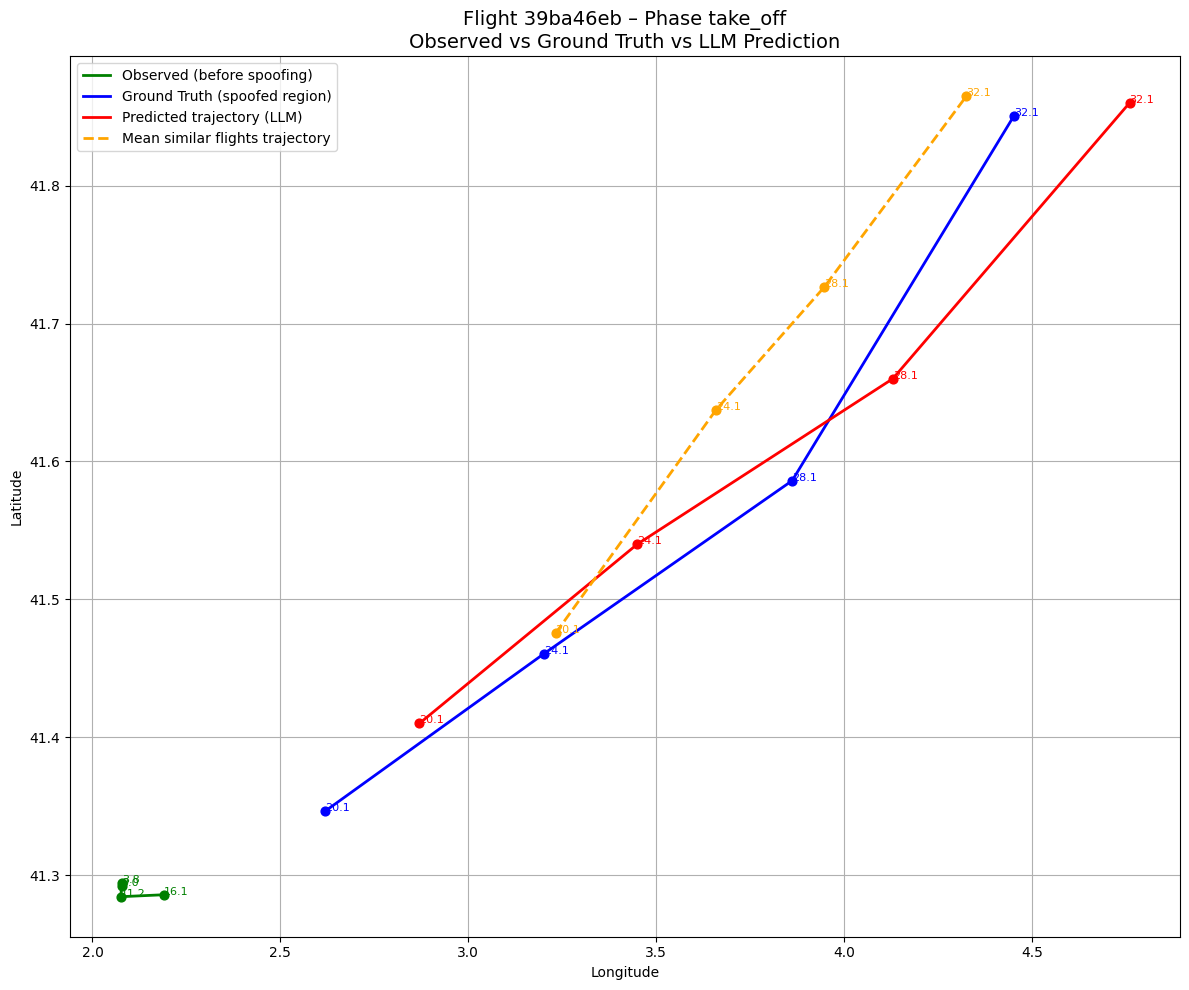


🚀 EXPÉRIMENTATION SUR VOL 39ba46eb | PHASE = cruising



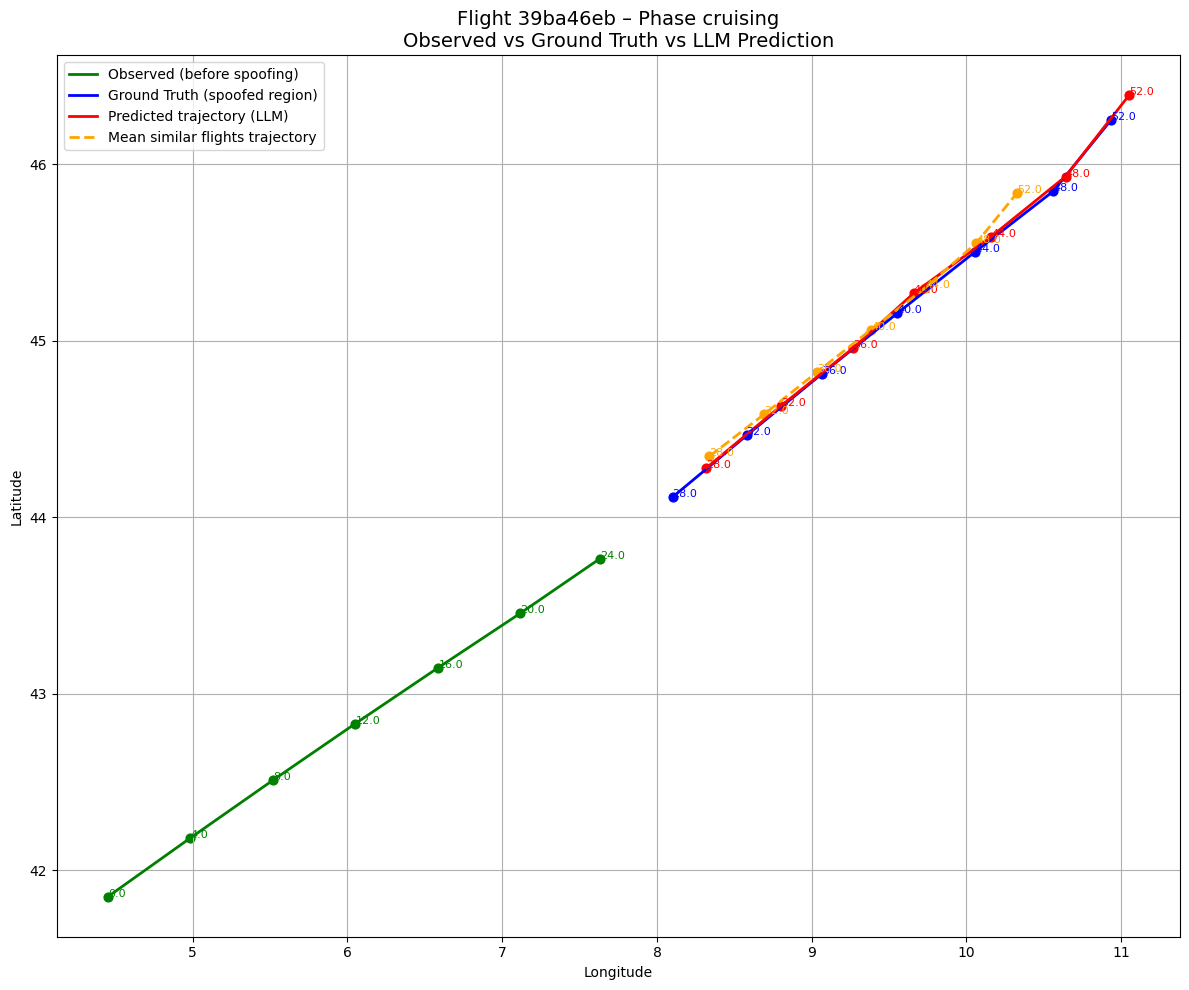


🚀 EXPÉRIMENTATION SUR VOL 39ba46eb | PHASE = landing



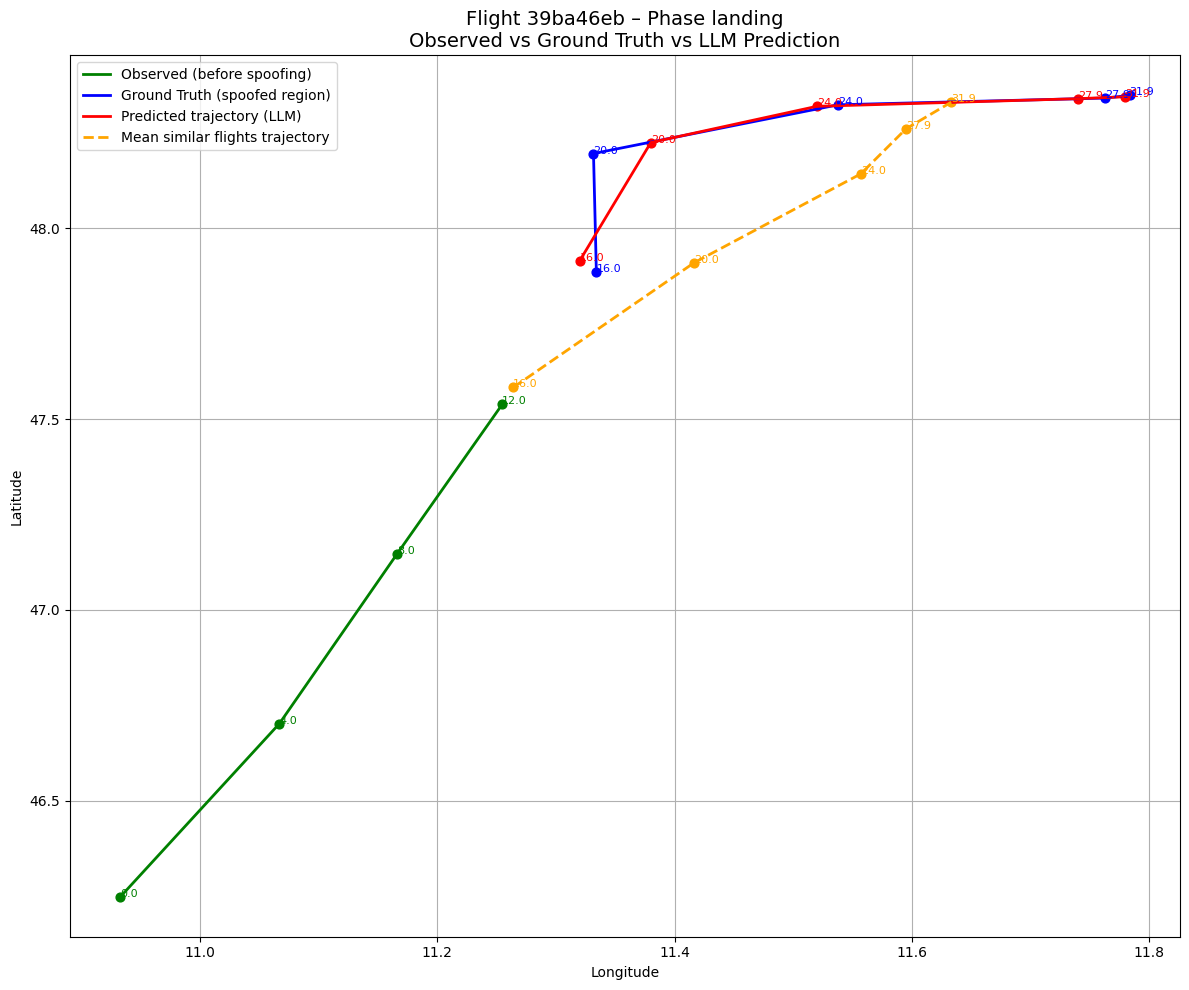

In [21]:
# ================================================
# Lancer l'expérience pour les 3 vols
# ================================================

FLIGHT_ID = "39ba46eb"

EXPERIMENTS = [
    (FLIGHT_ID, "take_off"),
    (FLIGHT_ID, "cruising"),
    (FLIGHT_ID, "landing"),
]

for flight_id, phase in EXPERIMENTS:
    m = run_experiment_for_flight(flight_id, phase, with_feedback_loop=True)

# m.save("map_output.html")

In [ ]:
import random

def calculate_mean_haversine_error(
    flight_ids_by_phase,
    k=5,
    batch_size=None
):
    errors_takeoff = []
    errors_cruising = []
    errors_landing = []

    similar_flight_errors_takeoff = []
    similar_flight_errors_cruising = []
    similar_flight_errors_landing = []

    mean_num_token_takeoff = 0
    mean_num_token_cruising = 0
    mean_num_token_landing = 0

    counter_takeoff = 0
    counter_cruising = 0
    counter_landing = 0

    # ======================================================
    # TAKE OFF
    # ======================================================
    for flight_id in flight_ids_by_phase["take_off"]:
        try:
            _, _, _, error, _, similar_error, num_tokens = predict_flight(
                flight_id, "take_off",
                with_feedback_loop=True,
                k=k,
                batch_size=batch_size
            )
            errors_takeoff.append((error, flight_id))
            similar_flight_errors_takeoff.append(similar_error)
            mean_num_token_takeoff += num_tokens
            counter_takeoff += 1
            print(f"counter take off: {counter_takeoff}")
        except:
            continue

    # ======================================================
    # CRUISING
    # ======================================================
    for flight_id in flight_ids_by_phase["cruising"]:
        try:
            _, _, _, error, _, similar_error, num_tokens = predict_flight(
                flight_id, "cruising",
                with_feedback_loop=True,
                k=k,
                batch_size=batch_size
            )
            errors_cruising.append((error, flight_id))
            similar_flight_errors_cruising.append(similar_error)
            mean_num_token_cruising += num_tokens
            counter_cruising += 1
            print(f"counter cruising: {counter_cruising}")
        except:
            continue

    # ======================================================
    # LANDING
    # ======================================================
    for flight_id in flight_ids_by_phase["landing"]:
        try:
            _, _, _, error, _, similar_error, num_tokens = predict_flight(
                flight_id, "landing",
                with_feedback_loop=True,
                k=k,
                batch_size=batch_size
            )
            errors_landing.append((error, flight_id))
            similar_flight_errors_landing.append(similar_error)
            mean_num_token_landing += num_tokens
            counter_landing += 1
            print(f"counter landing: {counter_landing}")
        except:
            continue

    # ======================================================
    # Means
    # ======================================================
    mean_num_token_takeoff = (
        mean_num_token_takeoff / counter_takeoff if counter_takeoff > 0 else None
    )
    mean_num_token_cruising = (
        mean_num_token_cruising / counter_cruising if counter_cruising > 0 else None
    )
    mean_num_token_landing = (
        mean_num_token_landing / counter_landing if counter_landing > 0 else None
    )

    return (
        errors_takeoff,
        similar_flight_errors_takeoff,
        errors_cruising,
        similar_flight_errors_cruising,
        errors_landing,
        similar_flight_errors_landing,
        mean_num_token_takeoff,
        mean_num_token_cruising,
        mean_num_token_landing
    )


In [ ]:
with open("test_sample.json", "r", encoding="utf-8") as f:
    flight_ids_by_phase = json.load(f)

errors_takeoff, similar_flight_error_takeoff, errors_cruising, similar_flight_error_cruising, errors_landing, similar_flight_error_landing, _, _, _ = calculate_mean_haversine_error(flight_ids_by_phase, k=5)

results = {
    "RAG": 
           {"take_off": errors_takeoff, 
            "cruising": errors_cruising, 
            "landing": errors_landing}, 
}

In [ ]:
with open("MEAN_HAVERSINE_RAG.json", "w", encoding="utf-8") as f:
    json.dump(results, f)

In [9]:
import json
import numpy as np

# Load JSON file
with open("MEAN_HAVERSINE_RAG.json", "r", encoding="utf-8") as f:
    data = json.load(f)

rag_data = data["RAG"]

stats = {}

for phase, values in rag_data.items():
    values_array = np.array(values)

    mean_val = round(np.mean(values_array), 2)
    median_val = round(np.median(values_array), 2)
    std_val = round(np.std(values_array), 2)

    stats[phase] = {
        "mean": mean_val,
        "median": median_val,
        "std": std_val
    }

# Print results
for phase, metrics in stats.items():
    print(f"\nPhase: {phase}")
    print(f"Mean   : {metrics['mean']} km")
    print(f"Median : {metrics['median']} km")
    print(f"Std    : {metrics['std']} km")


Phase: take_off
Mean   : 16.15 km
Median : 15.2 km
Std    : 3.6 km

Phase: cruising
Mean   : 9.2 km
Median : 9.8 km
Std    : 3.0 km

Phase: landing
Mean   : 2.5 km
Median : 2.3 km
Std    : 1.31 km
